In [9]:
import os
import io
import zipfile
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ROUND 1

In [24]:
zip_file_path = '../data/logs/round_1/272312.zip'

In [25]:
with zipfile.ZipFile(zip_file_path, 'r') as archive:
    files = archive.namelist()
    json_filename = [f for f in files if f[-4:]=='json']
    log_filename = [f for f in files if f[-3:]=='log']
    assert len(json_filename) == 1, "More than one json file in the log archive"
    assert len(log_filename) == 1, "More than one log file in the log archive"
    json_filename = json_filename[0]
    log_filename = log_filename[0]
    
    with archive.open(json_filename) as json_file:
        data_json = json.load(json_file)
    with archive.open(log_filename) as log_file:
        data_log = json.load(log_file)

In [26]:
data_json.keys()

dict_keys(['round', 'status', 'profit', 'activitiesLog', 'graphLog', 'positions'])

In [27]:
data_log.keys()

dict_keys(['submissionId', 'activitiesLog', 'logs', 'tradeHistory'])

In [28]:
activities = pd.read_csv(io.StringIO(data_log['activitiesLog']), sep=';')
trades = pd.DataFrame(data_log['tradeHistory'])

In [7]:
price_pepper = activities[activities['product'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
price_osmium = activities[activities['product'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')
trades_pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
trades_osmium = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')

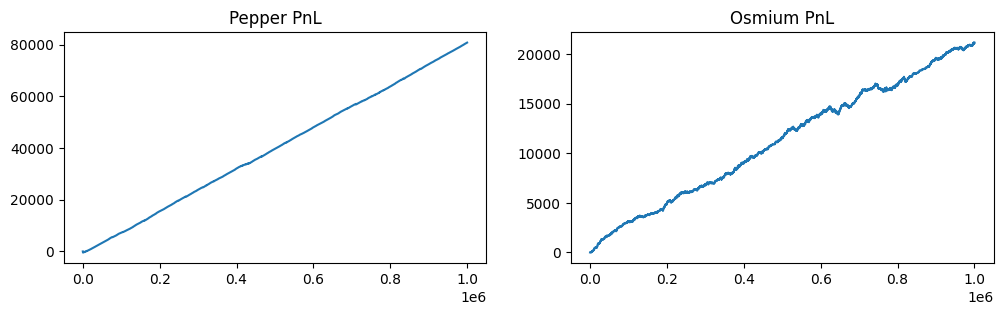

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot(price_pepper['profit_and_loss'])
ax[0].set_title('Pepper PnL')
ax[1].plot(price_osmium['profit_and_loss'])
ax[1].set_title('Osmium PnL')
plt.show()

In [9]:
print(f'Pepper Final PnL: {price_pepper['profit_and_loss'].iloc[-1]}')
print(f'Pepper Min PnL: {price_pepper['profit_and_loss'].min()}')
print(f'Osmium Final PnL: {price_osmium['profit_and_loss'].iloc[-1]}')
print(f'Osmium Min PnL: {price_osmium['profit_and_loss'].min()}')

Pepper Final PnL: 80769.25
Pepper Min PnL: -456.5
Osmium Final PnL: 21144.9375
Osmium Min PnL: -11.88671875


In [10]:
trades_pepper = trades_pepper.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_pepper = trades_pepper.assign(position=lambda x: np.cumsum(x['traded']))
trades_osmium = trades_osmium.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_osmium = trades_osmium.assign(position=lambda x: np.cumsum(x['traded']))

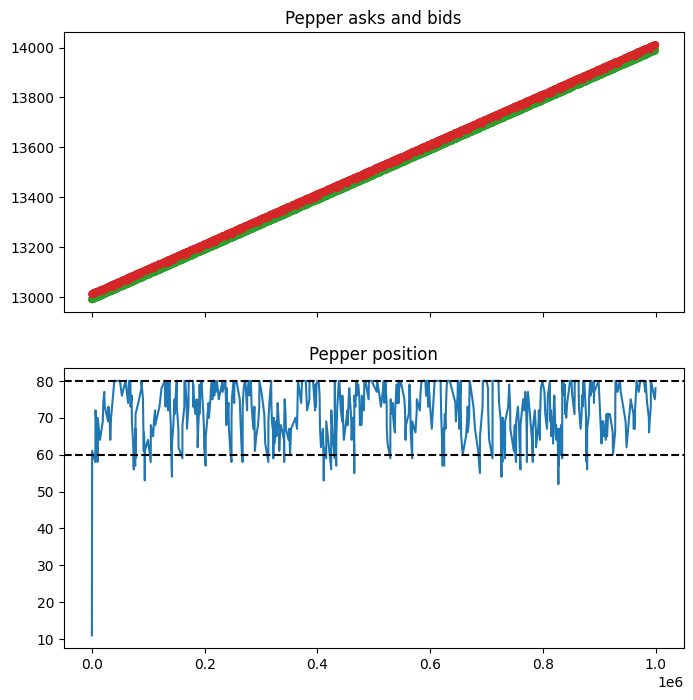

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
ax[0].scatter(price_pepper.index, price_pepper['bid_price_1'], s=price_pepper['bid_volume_1'], c='tab:green')
ax[0].scatter(price_pepper.index, price_pepper['ask_price_1'], s=price_pepper['ask_volume_1'], c='tab:red')
ax[0].set_title('Pepper asks and bids')
ax[1].plot(trades_pepper['position'])
ax[1].set_title('Pepper position')
ax[1].axhline(60, c='k', linestyle='dashed')
ax[1].axhline(80, c='k', linestyle='dashed')
plt.show()

In [12]:
edge_to_mean = 10000 - price_osmium['ask_price_1']  # Profit expected when reverting up to mean
half_spread = price_osmium['ask_price_1'] - price_osmium['mid_price']  # Cost paid to cross the spread
snap_back_buys = edge_to_mean > (half_spread + 1)

edge_to_mean = price_osmium['bid_price_1'] - 10000  # Profit expected when crashing down to mean
half_spread = price_osmium['mid_price'] - price_osmium['bid_price_1']  # Cost paid to cross the spread
snap_back_sells = edge_to_mean > (half_spread + 1)

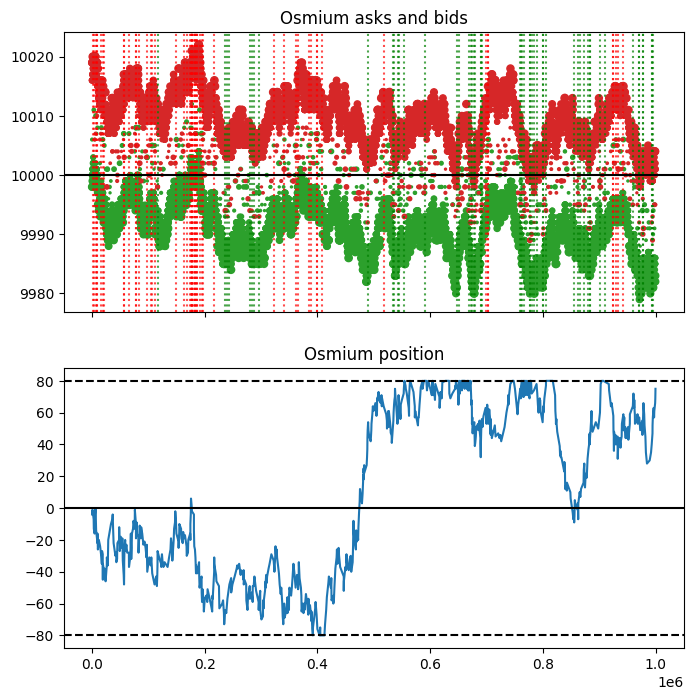

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
ax[0].scatter(price_osmium.index, price_osmium['bid_price_1'], s=price_osmium['bid_volume_1'], c='tab:green')
ax[0].scatter(price_osmium.index, price_osmium['ask_price_1'], s=price_osmium['ask_volume_1'], c='tab:red')
ax[0].axhline(10000, c='k')
for x in snap_back_buys[snap_back_buys].index:
    ax[0].axvline(x=x, color='green', linestyle='dotted', alpha=0.7)
for x in snap_back_sells[snap_back_sells].index:
    ax[0].axvline(x=x, color='red', linestyle='dotted', alpha=0.7)
ax[0].set_title('Osmium asks and bids')
ax[1].plot(trades_osmium['position'])
ax[1].axhline(0, c='k')
ax[1].axhline(80, c='k', linestyle='dashed')
ax[1].axhline(-80, c='k', linestyle='dashed')
ax[1].set_title('Osmium position')
plt.show()

# ROUND 2

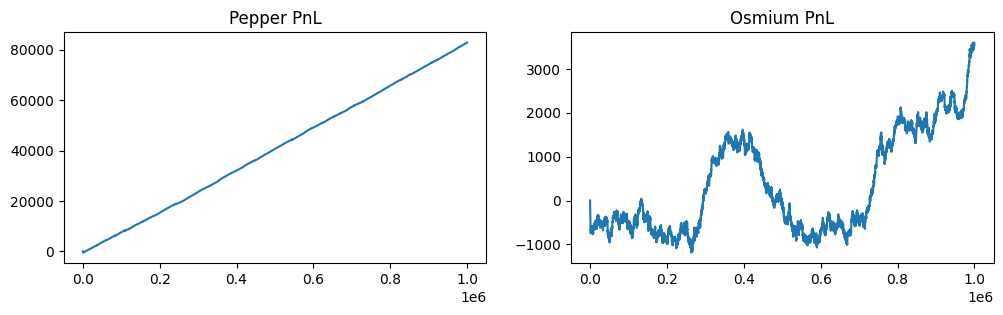

In [34]:
zip_file_path = '../data/logs/round_2/final/362301.zip'
with zipfile.ZipFile(zip_file_path, 'r') as archive:
    files = archive.namelist()
    json_filename = [f for f in files if f[-4:]=='json']
    log_filename = [f for f in files if f[-3:]=='log']
    assert len(json_filename) == 1, "More than one json file in the log archive"
    assert len(log_filename) == 1, "More than one log file in the log archive"
    json_filename = json_filename[0]
    log_filename = log_filename[0]
    
    with archive.open(json_filename) as json_file:
        data_json = json.load(json_file)
    with archive.open(log_filename) as log_file:
        data_log = json.load(log_file)

activities = pd.read_csv(io.StringIO(data_log['activitiesLog']), sep=';')
trades = pd.DataFrame(data_log['tradeHistory'])

price_pepper = activities[activities['product'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
price_osmium = activities[activities['product'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')
trades_pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
trades_osmium = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot(price_pepper['profit_and_loss'])
ax[0].set_title('Pepper PnL')
ax[1].plot(price_osmium['profit_and_loss'])
ax[1].set_title('Osmium PnL')
plt.show()

In [36]:
activities

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,ASH_COATED_OSMIUM,9963,13,9960,21,NaN,NaN,9979,13,9981,21,NaN,NaN,9971.0,0.000000
1,2,0,INTARIAN_PEPPER_ROOT,13993,9,13989,25,NaN,NaN,14007,9,14011,25,NaN,NaN,14000.0,0.000000
2,2,100,INTARIAN_PEPPER_ROOT,13993,8,13989,22,NaN,NaN,14008,8,14011,22,NaN,NaN,14000.5,-62.101562
3,2,100,ASH_COATED_OSMIUM,9963,15,9960,26,NaN,NaN,9979,15,9981,26,NaN,NaN,9971.0,-67.406250
4,2,200,INTARIAN_PEPPER_ROOT,13993,9,13989,22,NaN,NaN,14008,9,14011,22,NaN,NaN,14000.5,-123.593750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2,999700,INTARIAN_PEPPER_ROOT,14992,11,14988,23,NaN,NaN,15008,11,15011,23,NaN,NaN,15000.0,82804.375000
19996,2,999800,INTARIAN_PEPPER_ROOT,14992,9,14988,24,NaN,NaN,15008,9,15012,24,NaN,NaN,15000.0,82812.125000
19997,2,999800,ASH_COATED_OSMIUM,9990,10,9988,27,NaN,NaN,10006,10,10009,27,NaN,NaN,9998.0,3563.500000
19998,2,999900,INTARIAN_PEPPER_ROOT,14992,9,14988,25,NaN,NaN,15008,9,15012,25,NaN,NaN,15000.0,82820.125000


In [38]:
activities.to_csv('../data/raw/round_2/prices_round_2_day_2.csv', index=False, sep=';')
trades.to_csv('../data/raw/round_2/trades_round_2_day_2.csv', index=False, sep=';')

In [21]:
print(f'Pepper Final PnL: {price_pepper['profit_and_loss'].iloc[-1]}')
print(f'Pepper Min PnL: {price_pepper['profit_and_loss'].min()}')
print(f'Osmium Final PnL: {price_osmium['profit_and_loss'].iloc[-1]}')
print(f'Osmium Min PnL: {price_osmium['profit_and_loss'].min()}')

Pepper Final PnL: 82820.125
Pepper Min PnL: -458.1875
Osmium Final PnL: 3594.0
Osmium Min PnL: -1187.0625


In [22]:
price_pepper['profit_and_loss'].iloc[-1] + price_osmium['profit_and_loss'].iloc[-1]

np.float64(86414.125)

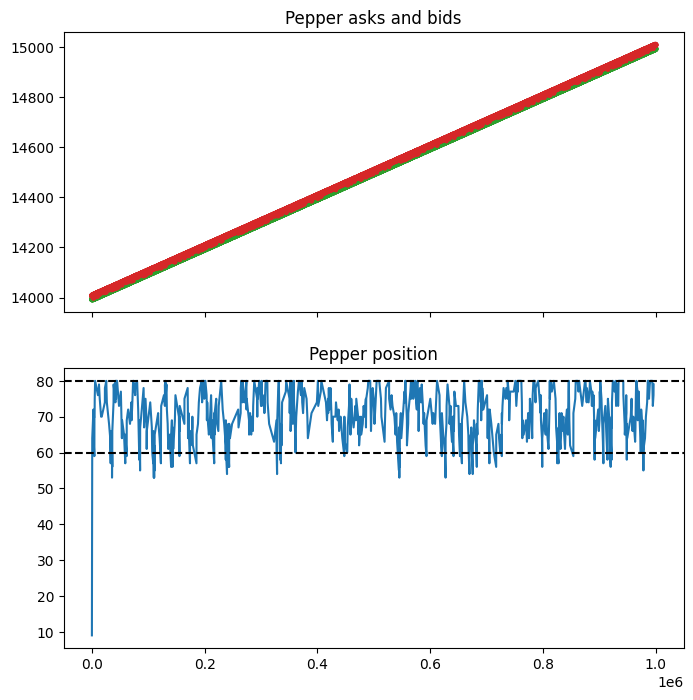

In [17]:
trades_pepper = trades_pepper.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_pepper = trades_pepper.assign(position=lambda x: np.cumsum(x['traded']))
trades_osmium = trades_osmium.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_osmium = trades_osmium.assign(position=lambda x: np.cumsum(x['traded']))

fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
ax[0].scatter(price_pepper.index, price_pepper['bid_price_1'], s=price_pepper['bid_volume_1'], c='tab:green')
ax[0].scatter(price_pepper.index, price_pepper['ask_price_1'], s=price_pepper['ask_volume_1'], c='tab:red')
ax[0].set_title('Pepper asks and bids')
ax[1].plot(trades_pepper['position'])
ax[1].set_title('Pepper position')
ax[1].axhline(60, c='k', linestyle='dashed')
ax[1].axhline(80, c='k', linestyle='dashed')
plt.show()

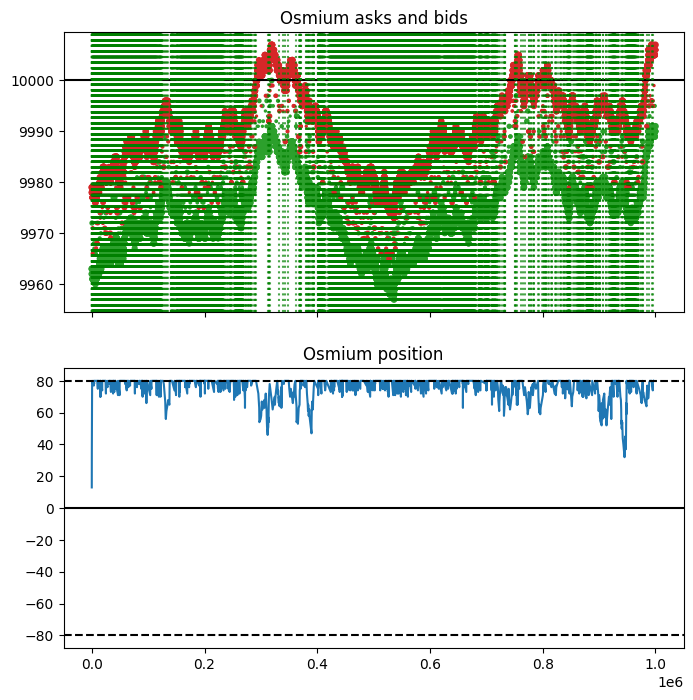

In [18]:
edge_to_mean = 10000 - price_osmium['ask_price_1']  # Profit expected when reverting up to mean
half_spread = price_osmium['ask_price_1'] - price_osmium['mid_price']  # Cost paid to cross the spread
snap_back_buys = edge_to_mean > (half_spread + 1)

edge_to_mean = price_osmium['bid_price_1'] - 10000  # Profit expected when crashing down to mean
half_spread = price_osmium['mid_price'] - price_osmium['bid_price_1']  # Cost paid to cross the spread
snap_back_sells = edge_to_mean > (half_spread + 1)

fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
ax[0].scatter(price_osmium.index, price_osmium['bid_price_1'], s=price_osmium['bid_volume_1'], c='tab:green')
ax[0].scatter(price_osmium.index, price_osmium['ask_price_1'], s=price_osmium['ask_volume_1'], c='tab:red')
ax[0].axhline(10000, c='k')
for x in snap_back_buys[snap_back_buys].index:
    ax[0].axvline(x=x, color='green', linestyle='dotted', alpha=0.7)
for x in snap_back_sells[snap_back_sells].index:
    ax[0].axvline(x=x, color='red', linestyle='dotted', alpha=0.7)
ax[0].set_title('Osmium asks and bids')
ax[1].plot(trades_osmium['position'])
ax[1].axhline(0, c='k')
ax[1].axhline(80, c='k', linestyle='dashed')
ax[1].axhline(-80, c='k', linestyle='dashed')
ax[1].set_title('Osmium position')
plt.show()

# ROUND 3

In [2]:
def get_thrs(price_df, ema_mean, ema_std):
    ema_var = ema_std ** 2
    
    window_size = 10000
    alpha = 2 / (window_size + 1)
    
    estimated_means = []
    estimated_stds = []
    
    # 3. EMA Updating Loop
    for price in price_df['mid_price']:
        # Calculate difference from the *old* mean
        diff = price - ema_mean
        
        # Update Variance FIRST (Mathematically requires the difference from the old mean)
        ema_var = (1 - alpha) * (ema_var + alpha * (diff ** 2))
        
        # Update Mean SECOND
        ema_mean = ema_mean + (alpha * diff)
        
        # Calculate instantaneous dynamic standard deviation
        current_std = math.sqrt(ema_var)
        
        estimated_means.append(ema_mean)
        estimated_stds.append(current_std)
    
    # 4. Save to DataFrame
    price_df['estimated_mean'] = estimated_means
    price_df['estimated_std'] = estimated_stds

    return price_df

In [3]:
zip_file_path = '../data/logs/round_3/484985.zip'
with zipfile.ZipFile(zip_file_path, 'r') as archive:
    files = archive.namelist()
    json_filename = [f for f in files if f[-4:]=='json']
    log_filename = [f for f in files if f[-3:]=='log']
    assert len(json_filename) == 1, "More than one json file in the log archive"
    assert len(log_filename) == 1, "More than one log file in the log archive"
    json_filename = json_filename[0]
    log_filename = log_filename[0]
    
    with archive.open(json_filename) as json_file:
        data_json = json.load(json_file)
    with archive.open(log_filename) as log_file:
        data_log = json.load(log_file)

activities = pd.read_csv(io.StringIO(data_log['activitiesLog']), sep=';')
trades = pd.DataFrame(data_log['tradeHistory'])

In [4]:
total_pnl = 0

Hydro PnL: 32945.0


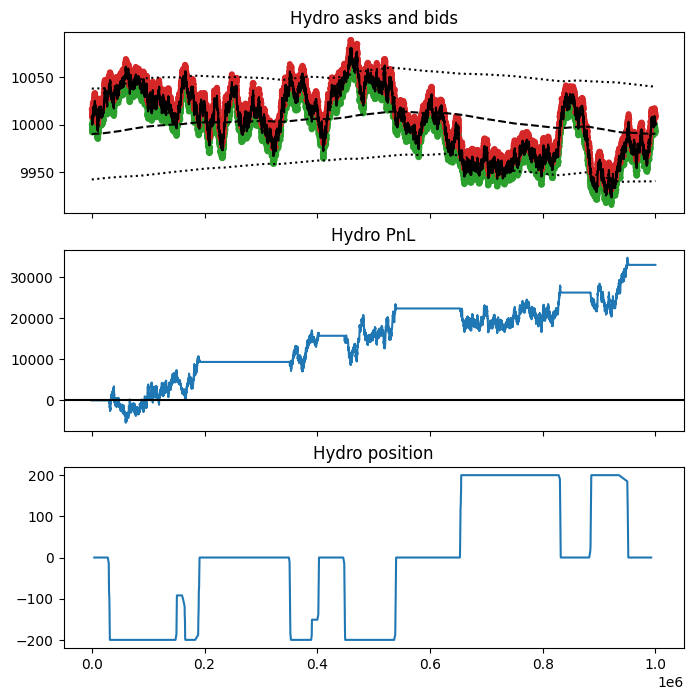

In [5]:
price_hydro = activities[activities['product'] == 'HYDROGEL_PACK'].reset_index(drop=True).set_index('timestamp')
trades_hydro = trades[trades['symbol'] == 'HYDROGEL_PACK'].reset_index(drop=True).set_index('timestamp')

trades_hydro = trades_hydro.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_hydro = trades_hydro.assign(position=lambda x: np.cumsum(x['traded']))

print(f"Hydro PnL: {price_hydro['profit_and_loss'].iloc[-1]}")
total_pnl += price_hydro['profit_and_loss'].iloc[-1]

ema_mean = 9990
ema_std = 32
price_hydro = get_thrs(price_hydro, ema_mean, ema_std)

fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
ax[0].scatter(price_hydro.index, price_hydro['bid_price_1'], s=price_hydro['bid_volume_1'], c='tab:green')
ax[0].scatter(price_hydro.index, price_hydro['ask_price_1'], s=price_hydro['ask_volume_1'], c='tab:red')
ax[0].plot(price_hydro['mid_price'], label='Filtered Mid Price', c='k')
ax[0].plot(price_hydro['estimated_mean'], label='EMA Mean', color='k', linestyle='dashed')
ax[0].plot(price_hydro['estimated_mean'] + 1.5 * price_hydro['estimated_std'], color='k', linestyle='dotted', label='+1.5 Std')
ax[0].plot(price_hydro['estimated_mean'] - 1.5 * price_hydro['estimated_std'], color='k', linestyle='dotted', label='-1.5 Std')
ax[0].set_title('Hydro asks and bids')
ax[1].plot(price_hydro['profit_and_loss'])
ax[1].axhline(0, c='k')
ax[1].set_title('Hydro PnL')
ax[2].plot(trades_hydro['position'])
ax[2].set_title('Hydro position')
plt.show()

Velvet PnL: 26021.0


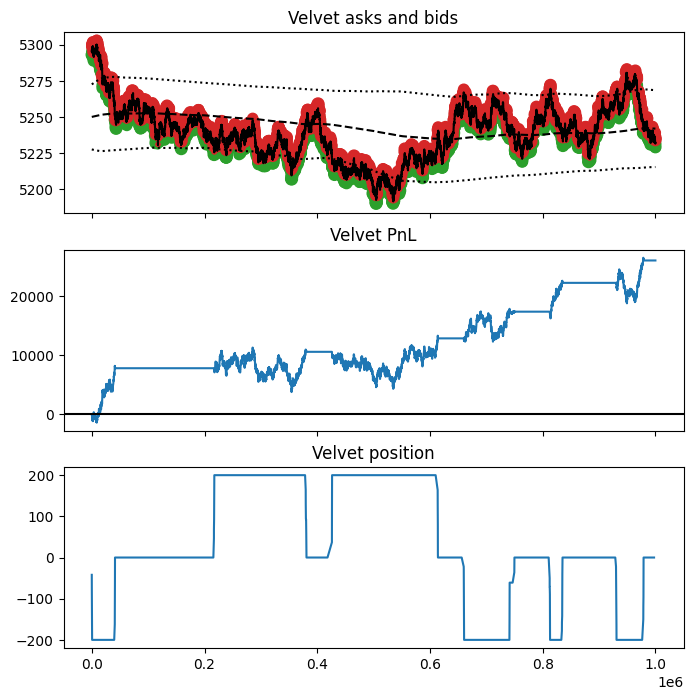

In [6]:
price_velvet = activities[activities['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True).set_index('timestamp')
trades_velvet = trades[trades['symbol'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True).set_index('timestamp')

trades_velvet = trades_velvet.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_velvet = trades_velvet.assign(position=lambda x: np.cumsum(x['traded']))

print(f"Velvet PnL: {price_velvet['profit_and_loss'].iloc[-1]}")
total_pnl += price_velvet['profit_and_loss'].iloc[-1]

ema_mean = 5250
ema_std = 15
price_velvet = get_thrs(price_velvet, ema_mean, ema_std)

fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
ax[0].scatter(price_velvet.index, price_velvet['bid_price_1'], s=price_velvet['bid_volume_1'], c='tab:green')
ax[0].scatter(price_velvet.index, price_velvet['ask_price_1'], s=price_velvet['ask_volume_1'], c='tab:red')
ax[0].plot(price_velvet['mid_price'], label='Filtered Mid Price', c='k')
ax[0].plot(price_velvet['estimated_mean'], label='EMA Mean', color='k', linestyle='dashed')
ax[0].plot(price_velvet['estimated_mean'] + 1.5 * price_velvet['estimated_std'], color='k', linestyle='dotted', label='+1.5 Std')
ax[0].plot(price_velvet['estimated_mean'] - 1.5 * price_velvet['estimated_std'], color='k', linestyle='dotted', label='-1.5 Std')
ax[0].set_title('Velvet asks and bids')
ax[1].plot(price_velvet['profit_and_loss'])
ax[1].axhline(0, c='k')
ax[1].set_title('Velvet PnL')
ax[2].plot(trades_velvet['position'])
ax[2].set_title('Velvet position')
plt.show()

Vev_4000 PnL: 17360.0
Vev_4500 PnL: 21031.0
Vev_5000 PnL: 32050.0
Vev_5100 PnL: 27579.0
Vev_5200 PnL: 16807.0
Vev_5300 PnL: 6152.0


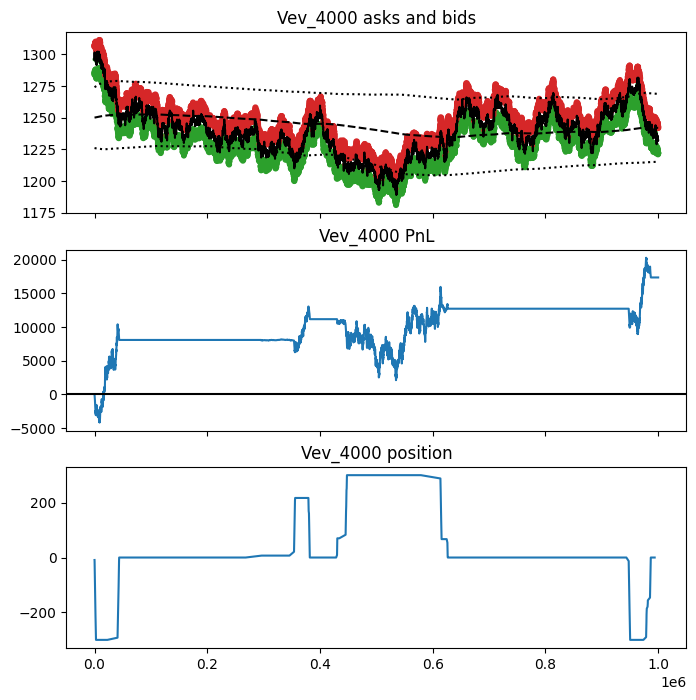

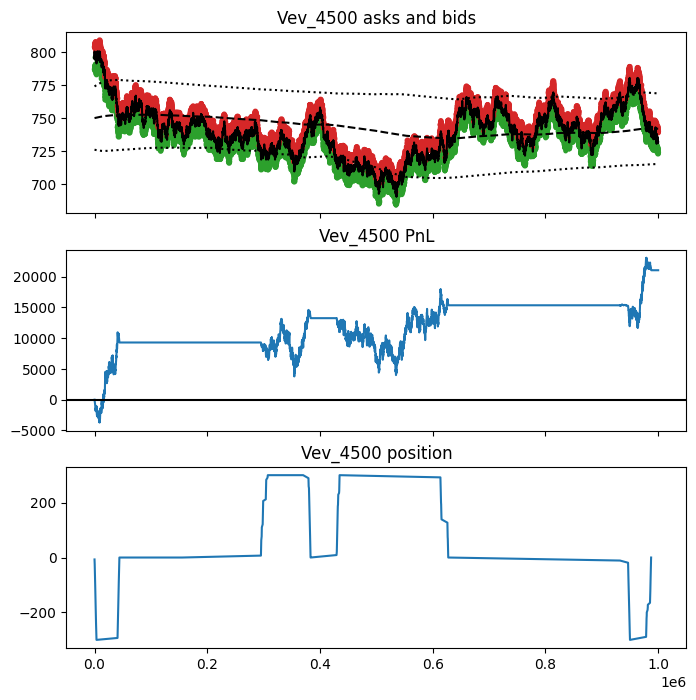

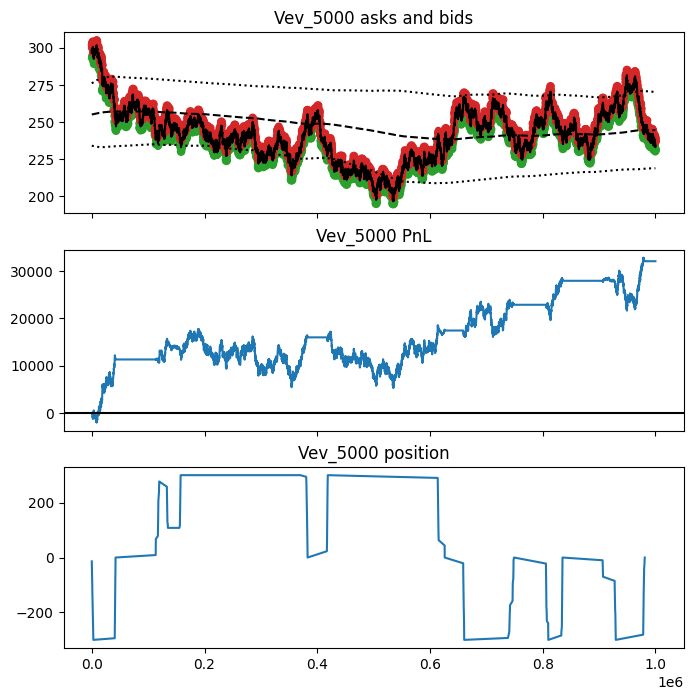

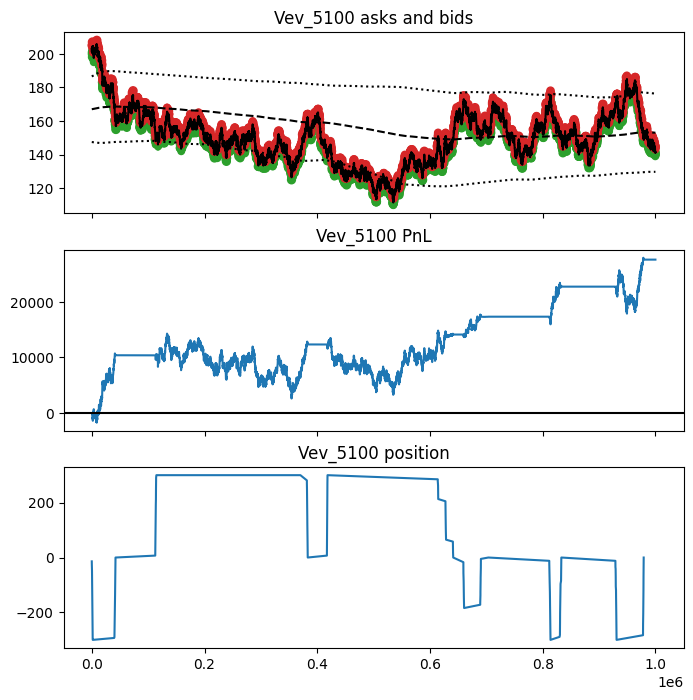

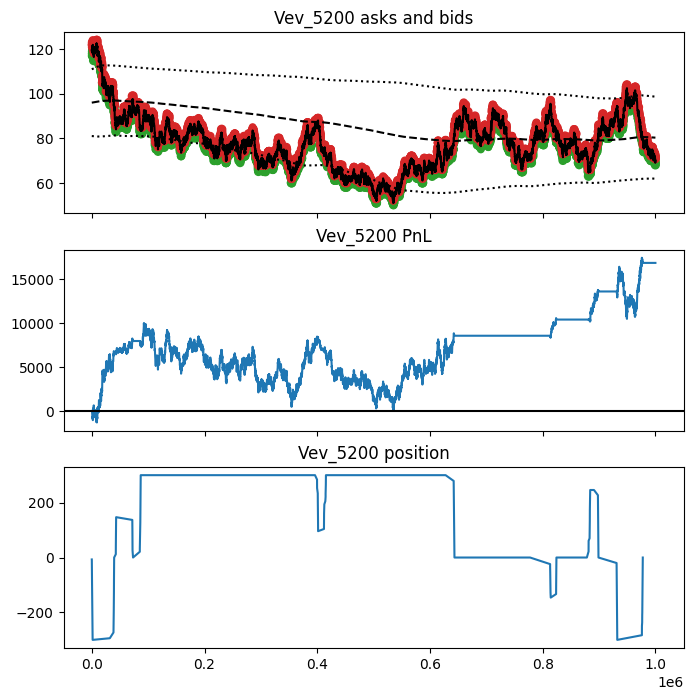

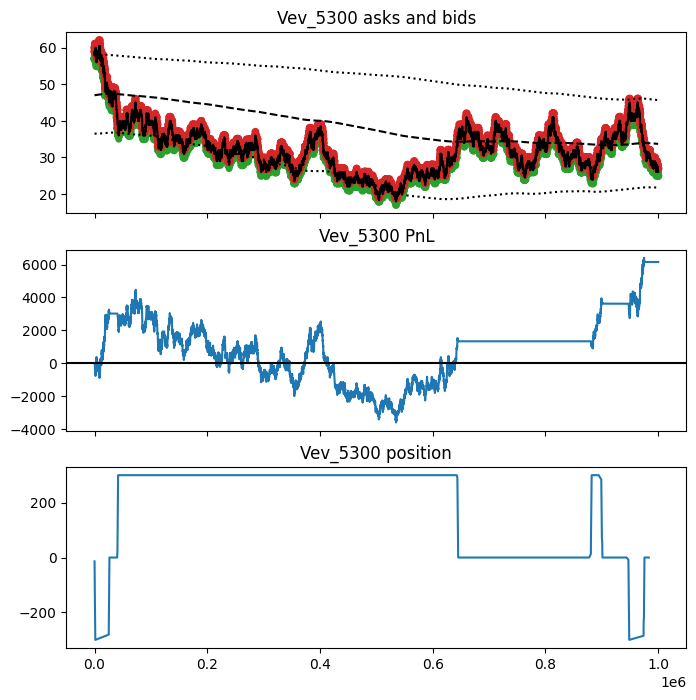

In [7]:
strikes = [4000, 4500, 5000, 5100, 5200, 5300]
price_vev, trades_vev = {}, {}
for strike in strikes:
    price_vev[strike] = activities[activities['product'] == f'VEV_{strike}'].reset_index(drop=True).set_index('timestamp')
    trades_vev[strike] = trades[trades['symbol'] == f'VEV_{strike}'].reset_index(drop=True).set_index('timestamp')
    trades_vev[strike] = trades_vev[strike].assign(
        traded=lambda x: np.where(
            x['buyer'] == 'SUBMISSION',
            x['quantity'],
            np.where(
                x['seller'] == 'SUBMISSION',
                -x['quantity'],
                0
            )
        )
    )
    trades_vev[strike] = trades_vev[strike].assign(position=lambda x: np.cumsum(x['traded']))

    print(f"Vev_{strike} PnL: {price_vev[strike]['profit_and_loss'].iloc[-1]}")
    total_pnl += price_vev[strike]['profit_and_loss'].iloc[-1]

CALL_CONFIGS = {
    4000: dict(limit=300, price_mean=1250, price_std=16, z_score_take_thr=1.2, vol_thr=15, mr_param=-0.05),
    4500: dict(limit=300, price_mean=750, price_std=16, z_score_take_thr=1.2, vol_thr=15, mr_param=-0.05),
    5000: dict(limit=300, price_mean=255, price_std=14, z_score_take_thr=1.2, vol_thr=15, mr_param=-0.05),
    5100: dict(limit=300, price_mean=167, price_std=13, z_score_take_thr=1.2, vol_thr=15, mr_param=-0.08),
    5200: dict(limit=300, price_mean=96,  price_std=10, z_score_take_thr=1.2, vol_thr=15, mr_param=-0.08),
    5300: dict(limit=300, price_mean=47,  price_std=7, z_score_take_thr=1.2, vol_thr=15, mr_param=-0.14),
}

for strike in strikes:
    ema_mean = CALL_CONFIGS[strike]['price_mean']
    ema_std = CALL_CONFIGS[strike]['price_std']
    price_vev[strike] = get_thrs(price_vev[strike], ema_mean, ema_std)
    
    fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
    ax[0].scatter(price_vev[strike].index, price_vev[strike]['bid_price_1'], s=price_vev[strike]['bid_volume_1'], c='tab:green')
    ax[0].scatter(price_vev[strike].index, price_vev[strike]['ask_price_1'], s=price_vev[strike]['ask_volume_1'], c='tab:red')
    ax[0].plot(price_vev[strike]['mid_price'], label='Filtered Mid Price', c='k')
    ax[0].plot(price_vev[strike]['estimated_mean'], label='EMA Mean', color='k', linestyle='dashed')
    ax[0].plot(price_vev[strike]['estimated_mean'] + 1.5 * price_vev[strike]['estimated_std'], color='k', linestyle='dotted', label='+1.5 Std')
    ax[0].plot(price_vev[strike]['estimated_mean'] - 1.5 * price_vev[strike]['estimated_std'], color='k', linestyle='dotted', label='-1.5 Std')
    ax[0].set_title(f'Vev_{strike} asks and bids')
    ax[1].plot(price_vev[strike]['profit_and_loss'])
    ax[1].axhline(0, c='k')
    ax[1].set_title(f'Vev_{strike} PnL')
    ax[2].plot(trades_vev[strike]['position'])
    ax[2].set_title(f'Vev_{strike} position')
    plt.show()

In [8]:
print(f"Total PnL: {total_pnl}")

Total PnL: 179945.0


# ROUND 4

In [10]:
def get_thrs(price_df, ema_mean, ema_std):
    ema_var = ema_std ** 2
    
    window_size = 10000
    alpha = 2 / (window_size + 1)
    
    estimated_means = []
    estimated_stds = []
    
    # 3. EMA Updating Loop
    for price in price_df['mid_price']:
        # Calculate difference from the *old* mean
        diff = price - ema_mean
        
        # Update Variance FIRST (Mathematically requires the difference from the old mean)
        ema_var = (1 - alpha) * (ema_var + alpha * (diff ** 2))
        
        # Update Mean SECOND
        ema_mean = ema_mean + (alpha * diff)
        
        # Calculate instantaneous dynamic standard deviation
        current_std = math.sqrt(ema_var)
        
        estimated_means.append(ema_mean)
        estimated_stds.append(current_std)
    
    # 4. Save to DataFrame
    price_df['estimated_mean'] = estimated_means
    price_df['estimated_std'] = estimated_stds

    return price_df

In [93]:
zip_file_path = '../data/logs/round_4/510277.zip'
with zipfile.ZipFile(zip_file_path, 'r') as archive:
    files = archive.namelist()
    json_filename = [f for f in files if f[-4:]=='json']
    log_filename = [f for f in files if f[-3:]=='log']
    assert len(json_filename) == 1, "More than one json file in the log archive"
    assert len(log_filename) == 1, "More than one log file in the log archive"
    json_filename = json_filename[0]
    log_filename = log_filename[0]
    
    with archive.open(json_filename) as json_file:
        data_json = json.load(json_file)
    with archive.open(log_filename) as log_file:
        data_log = json.load(log_file)

activities = pd.read_csv(io.StringIO(data_log['activitiesLog']), sep=';')
trades = pd.DataFrame(data_log['tradeHistory'])

In [94]:
total_pnl = 0

Hydro PnL: 5866.0


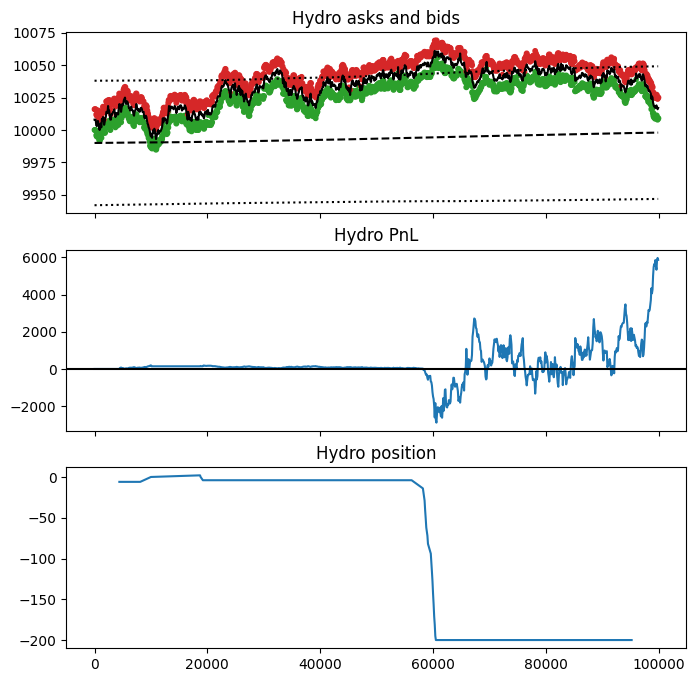

In [95]:
price_hydro = activities[activities['product'] == 'HYDROGEL_PACK'].reset_index(drop=True).set_index('timestamp')
trades_hydro = trades[trades['symbol'] == 'HYDROGEL_PACK'].reset_index(drop=True).set_index('timestamp')

trades_hydro = trades_hydro.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_hydro = trades_hydro.assign(position=lambda x: np.cumsum(x['traded']))

print(f"Hydro PnL: {price_hydro['profit_and_loss'].iloc[-1]}")
total_pnl += price_hydro['profit_and_loss'].iloc[-1]

ema_mean = 9990
ema_std = 32
price_hydro = get_thrs(price_hydro, ema_mean, ema_std)

fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
ax[0].scatter(price_hydro.index, price_hydro['bid_price_1'], s=price_hydro['bid_volume_1'], c='tab:green')
ax[0].scatter(price_hydro.index, price_hydro['ask_price_1'], s=price_hydro['ask_volume_1'], c='tab:red')
ax[0].plot(price_hydro['mid_price'], label='Filtered Mid Price', c='k')
ax[0].plot(price_hydro['estimated_mean'], label='EMA Mean', color='k', linestyle='dashed')
ax[0].plot(price_hydro['estimated_mean'] + 1.5 * price_hydro['estimated_std'], color='k', linestyle='dotted', label='+1.5 Std')
ax[0].plot(price_hydro['estimated_mean'] - 1.5 * price_hydro['estimated_std'], color='k', linestyle='dotted', label='-1.5 Std')
ax[0].set_title('Hydro asks and bids')
ax[1].plot(price_hydro['profit_and_loss'])
ax[1].axhline(0, c='k')
ax[1].set_title('Hydro PnL')
ax[2].plot(trades_hydro['position'])
ax[2].set_title('Hydro position')
plt.show()

Velvet PnL: 8334.0


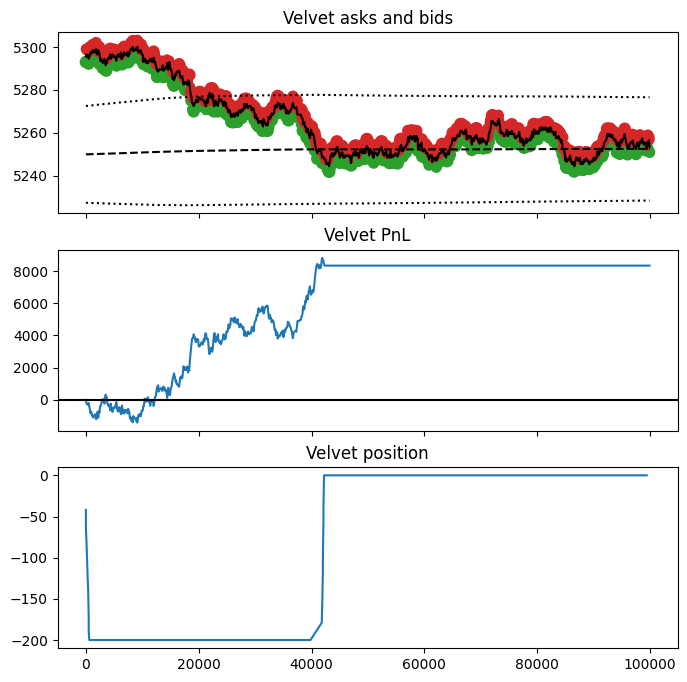

In [96]:
price_velvet = activities[activities['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True).set_index('timestamp')
trades_velvet = trades[trades['symbol'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True).set_index('timestamp')

trades_velvet = trades_velvet.assign(
    traded=lambda x: np.where(
        x['buyer'] == 'SUBMISSION',
        x['quantity'],
        np.where(
            x['seller'] == 'SUBMISSION',
            -x['quantity'],
            0
        )
    )
)
trades_velvet = trades_velvet.assign(position=lambda x: np.cumsum(x['traded']))

print(f"Velvet PnL: {price_velvet['profit_and_loss'].iloc[-1]}")
total_pnl += price_velvet['profit_and_loss'].iloc[-1]

ema_mean = 5250
ema_std = 15
price_velvet = get_thrs(price_velvet, ema_mean, ema_std)

fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
ax[0].scatter(price_velvet.index, price_velvet['bid_price_1'], s=price_velvet['bid_volume_1'], c='tab:green')
ax[0].scatter(price_velvet.index, price_velvet['ask_price_1'], s=price_velvet['ask_volume_1'], c='tab:red')
ax[0].plot(price_velvet['mid_price'], label='Filtered Mid Price', c='k')
ax[0].plot(price_velvet['estimated_mean'], label='EMA Mean', color='k', linestyle='dashed')
ax[0].plot(price_velvet['estimated_mean'] + 1.5 * price_velvet['estimated_std'], color='k', linestyle='dotted', label='+1.5 Std')
ax[0].plot(price_velvet['estimated_mean'] - 1.5 * price_velvet['estimated_std'], color='k', linestyle='dotted', label='-1.5 Std')
ax[0].set_title('Velvet asks and bids')
ax[1].plot(price_velvet['profit_and_loss'])
ax[1].axhline(0, c='k')
ax[1].set_title('Velvet PnL')
ax[2].plot(trades_velvet['position'])
ax[2].set_title('Velvet position')
plt.show()

Vev_4000 PnL: 8249.0
Vev_4500 PnL: 9520.0
Vev_5000 PnL: 12262.0
Vev_5100 PnL: 11256.0
Vev_5200 PnL: 8625.0
Vev_5300 PnL: 5120.0


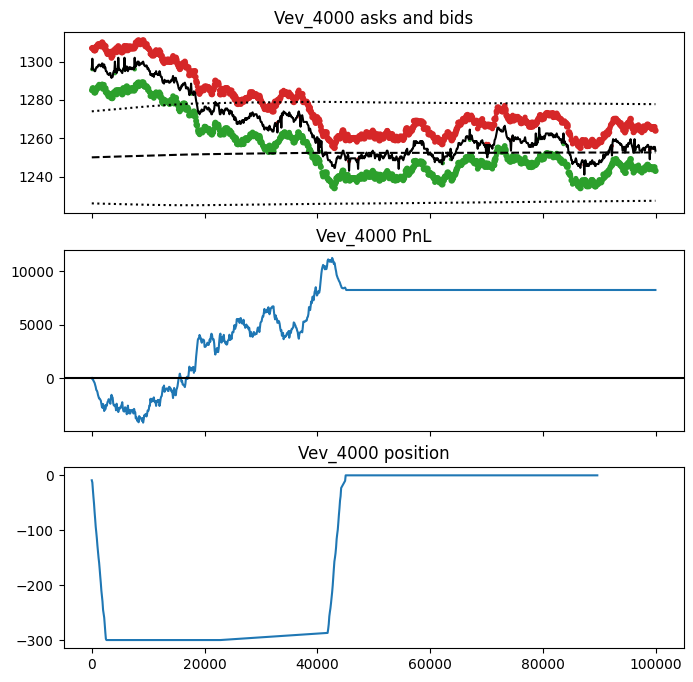

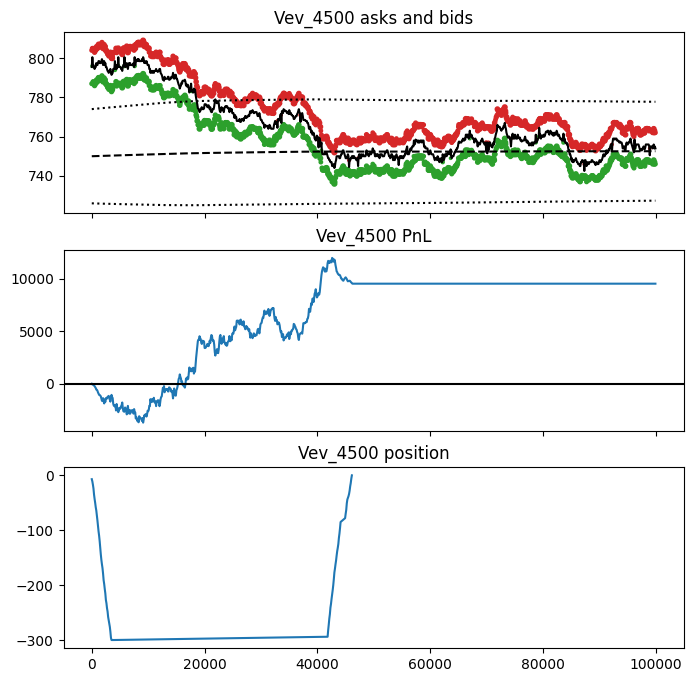

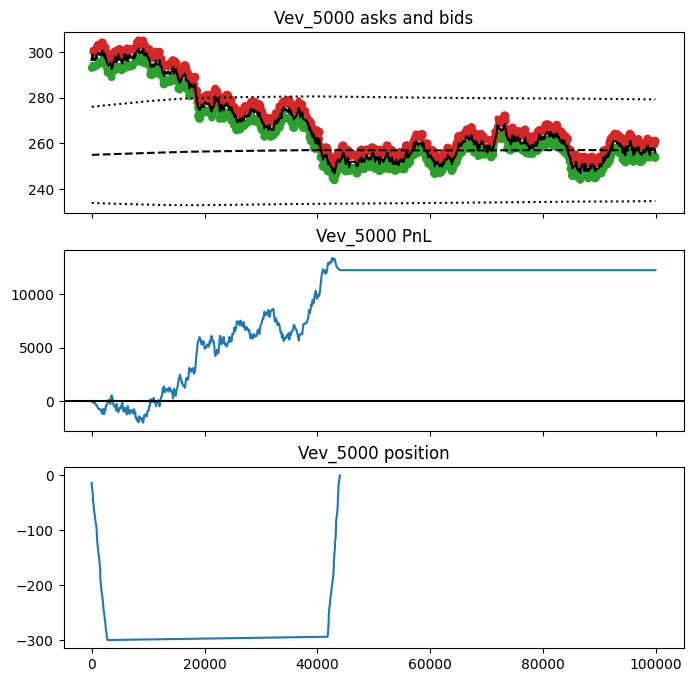

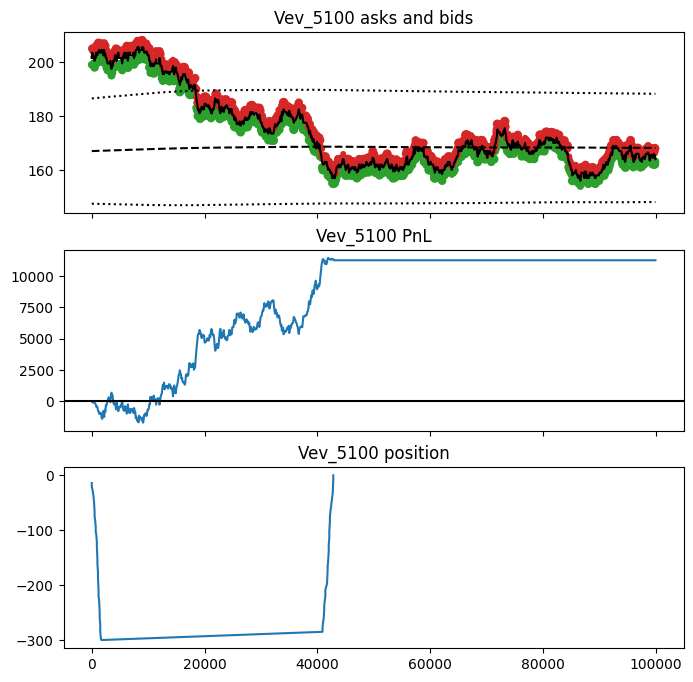

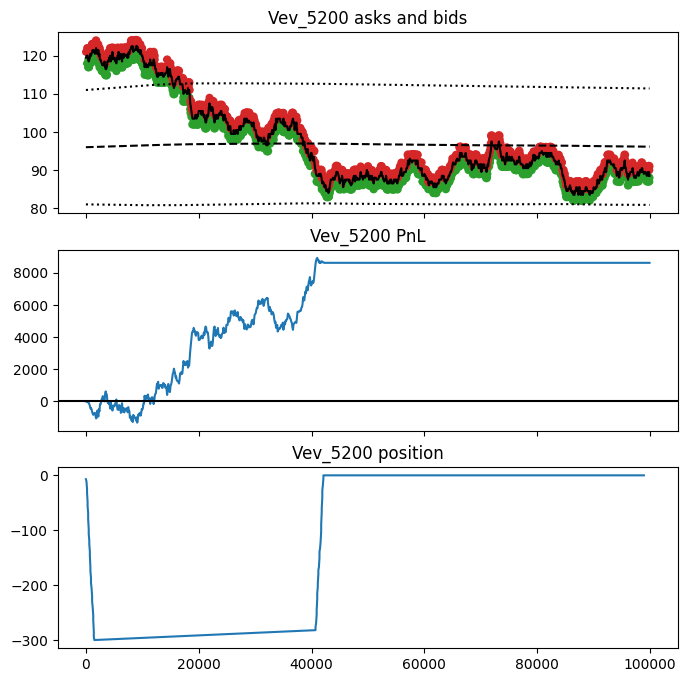

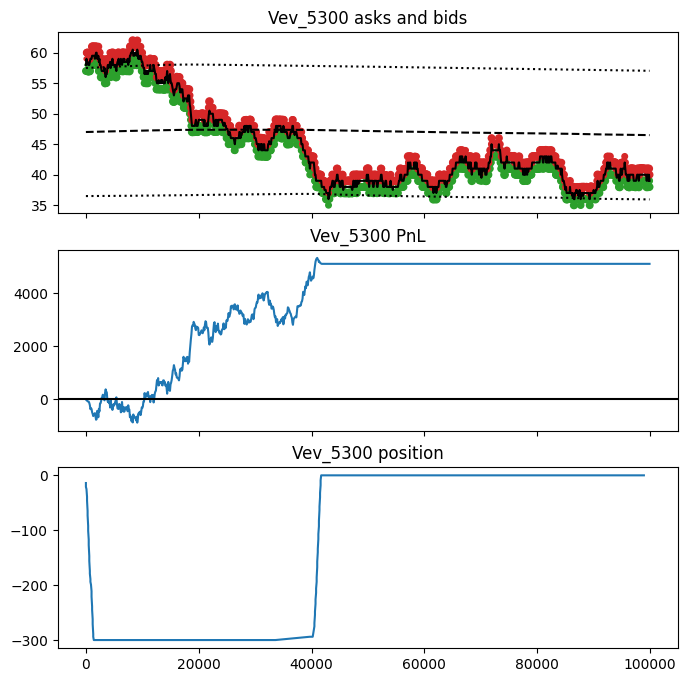

In [97]:
strikes = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500]
price_vev, trades_vev = {}, {}
for strike in strikes:
    price_vev[strike] = activities[activities['product'] == f'VEV_{strike}'].reset_index(drop=True).set_index('timestamp')
    trades_vev[strike] = trades[trades['symbol'] == f'VEV_{strike}'].reset_index(drop=True).set_index('timestamp')
    trades_vev[strike] = trades_vev[strike].assign(
        traded=lambda x: np.where(
            x['buyer'] == 'SUBMISSION',
            x['quantity'],
            np.where(
                x['seller'] == 'SUBMISSION',
                -x['quantity'],
                0
            )
        )
    )
    trades_vev[strike] = trades_vev[strike].assign(position=lambda x: np.cumsum(x['traded']))

    print(f"Vev_{strike} PnL: {price_vev[strike]['profit_and_loss'].iloc[-1]}")
    total_pnl += price_vev[strike]['profit_and_loss'].iloc[-1]

CALL_CONFIGS = {
    4000: dict(limit=300, price_mean=1248, price_std=18, z_score_take_thr=1.9, vol_thr=7, mr_param=-0.07),
    4500: dict(limit=300, price_mean=748, price_std=18, z_score_take_thr=1.7, vol_thr=15, mr_param=-0.05),
    5000: dict(limit=300, price_mean=251, price_std=17, z_score_take_thr=1.2, vol_thr=15, mr_param=-0.07),
    5100: dict(limit=300, price_mean=161, price_std=16, z_score_take_thr=1.2, vol_thr=15, mr_param=-0.07),
    5200: dict(limit=300, price_mean=89,  price_std=13, z_score_take_thr=1.1, vol_thr=15, mr_param=-0.1),
    5300: dict(limit=300, price_mean=41,  price_std=9, z_score_take_thr=1.0, vol_thr=13, mr_param=-0.16),
    5400: dict(limit=300, price_mean=13,  price_std=4, z_score_take_thr=1.0, vol_thr=11, mr_param=-0.29),
    5500: dict(limit=300, price_mean=5,  price_std=2, z_score_take_thr=1.0, vol_thr=15, mr_param=-0.24),
}

for strike in strikes:
    ema_mean = CALL_CONFIGS[strike]['price_mean']
    ema_std = CALL_CONFIGS[strike]['price_std']
    price_vev[strike] = get_thrs(price_vev[strike], ema_mean, ema_std)
    
    fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
    ax[0].scatter(price_vev[strike].index, price_vev[strike]['bid_price_1'], s=price_vev[strike]['bid_volume_1'], c='tab:green')
    ax[0].scatter(price_vev[strike].index, price_vev[strike]['ask_price_1'], s=price_vev[strike]['ask_volume_1'], c='tab:red')
    ax[0].plot(price_vev[strike]['mid_price'], label='Filtered Mid Price', c='k')
    ax[0].plot(price_vev[strike]['estimated_mean'], label='EMA Mean', color='k', linestyle='dashed')
    ax[0].plot(price_vev[strike]['estimated_mean'] + 1.5 * price_vev[strike]['estimated_std'], color='k', linestyle='dotted', label='+1.5 Std')
    ax[0].plot(price_vev[strike]['estimated_mean'] - 1.5 * price_vev[strike]['estimated_std'], color='k', linestyle='dotted', label='-1.5 Std')
    ax[0].set_title(f'Vev_{strike} asks and bids')
    ax[1].plot(price_vev[strike]['profit_and_loss'])
    ax[1].axhline(0, c='k')
    ax[1].set_title(f'Vev_{strike} PnL')
    ax[2].plot(trades_vev[strike]['position'])
    ax[2].set_title(f'Vev_{strike} position')
    plt.show()

In [98]:
print(f"Total PnL: {total_pnl}")

Total PnL: 69232.0
